/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/marilene/.local/lib/python3.10/site-packages/sklearn/linear_mode

              precision    recall  f1-score   support

           0       0.64      0.63      0.63        62
           1       0.73      0.73      0.73        62
           2       0.61      0.53      0.57        62
           3       0.69      0.50      0.58        62
           4       0.57      0.53      0.55        62
           5       0.54      0.77      0.64        62
           6       0.53      0.40      0.46        62
           7       0.68      0.82      0.74        62
           8       0.75      0.77      0.76        62
           9       0.82      0.85      0.83        62

    accuracy                           0.65       620
   macro avg       0.66      0.65      0.65       620
weighted avg       0.66      0.65      0.65       620

Cross-Validation Accuracy: 0.457 (+/- 0.048)


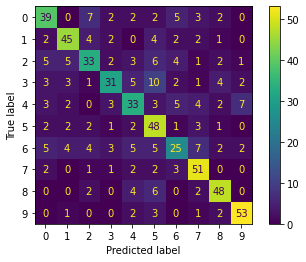

In [24]:
import pandas as pd
from numpy import mean, std
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.multiclass import OneVsRestClassifier
from matplotlib import pyplot
import numpy as np

# Load and preprocess data
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')

y_train = y_train.idxmax(axis=1)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Balance dataset with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train_encoded)

# Feature selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
X_train_selected = selector.fit_transform(X_train_balanced, y_train_balanced)

# Hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'penalty': ['l1', 'l2', 'elasticnet'],
    'max_iter': [100, 200, 500]
}
logreg = LogisticRegression()
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_selected, y_train_balanced)

# Train best model
best_model = OneVsRestClassifier(grid_search.best_estimator_)
best_model.fit(X_train_selected, y_train_balanced)

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
y_pred = best_model.predict(X_train_selected)
print(classification_report(y_train_balanced, y_pred))
ConfusionMatrixDisplay.from_predictions(y_train_balanced, y_pred)

# cross-validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
cross_val_scores = cross_val_score(best_model, X_train_selected, y_train_balanced, cv=cv, scoring='accuracy', n_jobs=-1)

# cross-validation printen
print(f"Cross-Validation Accuracy: {mean(cross_val_scores):.3f} (+/- {std(cross_val_scores):.3f})")